##  Day 55 — RandomizedSearchCV

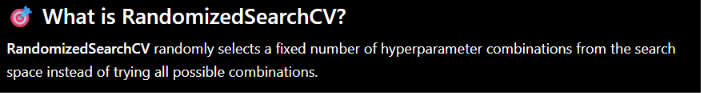 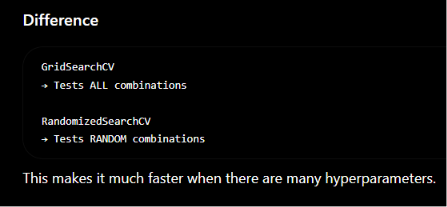

In [7]:
# Step 1: Import Libraries

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split                                                                                                                                                                                                                                                                                              
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [10]:
 # Step 2: Load Dataset

iris = load_iris()
X = iris.data
y = iris.target

In [14]:
# Step 3: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [16]:
# Step 4: Create Model

rf = RandomForestClassifier(random_state = 42)

In [29]:
# Step 5: Create Parameter Distribution

param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_split': [2, 5, 10]
}

In [30]:
# Step 6: Apply RandomizedSearchCV

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=5, cv=5, random_state=42)

# Meaning of Parameters
# n_iter=5
# → Randomly tests only 5 parameter combinations

# cv=5
# → 5-Fold Cross Validation

In [31]:
 # Step 7: Train the Model

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=5,
                   param_distributions={'max_depth': [2, 4, 6, 8, 10],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 300]},
                   random_state=42)

In [32]:
# Step 8: Best Parameters

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 8}


In [34]:
# Step 9: Prediction

y_pred = random_search.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 1.0


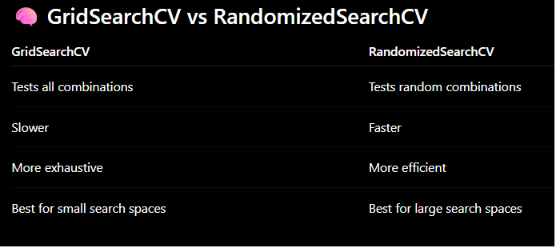